# Разбор датасета MNIST
Реализуем MLP и CNN модели и посмотрим какой метрики получится добиться

In [1]:
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.nn import functional as F

from torch.utils.data import TensorDataset, DataLoader
import random
from tqdm.notebook import tqdm

import copy

sns.set(style="darkgrid", font_scale=1.4)

In [2]:
# Reduce stochasticity

SEED = 42

# PyTorch
torch.manual_seed(SEED)

# CUDA (GPU)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups

# NumPy
np.random.seed(SEED)

# Python's built-in random
random.seed(SEED)

In [3]:
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)

In [4]:
import os
from torchvision.datasets import MNIST
from torchvision import transforms as tfs


data_tfs = tfs.Compose([
    tfs.ToTensor(),
    tfs.Normalize((0.5), (0.5))
])

root = './'
train_dataset_MNIST = MNIST(root, train=True,  transform=data_tfs, download=True)
val_dataset_MNIST  = MNIST(root, train=False, transform=data_tfs, download=True)

train_dataloader_MNIST = DataLoader(train_dataset_MNIST, batch_size=128, shuffle=True)
valid_dataloader_MNIST = DataLoader(val_dataset_MNIST, batch_size=128, shuffle=False)

loaders_MNIST = {"train": train_dataloader_MNIST, "valid": valid_dataloader_MNIST}

100%|██████████| 9.91M/9.91M [00:00<00:00, 97.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 6.23MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 86.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.63MB/s]


In [28]:
activation = nn.ELU()

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ELU(),
    nn.Linear(128, 128),
    nn.ELU(),
    nn.Linear(128, 10)
)

In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
def fit_one_epoch(model, train_dataloader, optimizer, loss_func):
  '''
  args:
    model - модель для обучения
    train_dataloader - loader с выборкой для обучения модели
    optimizer - оптимизатор, взятый из модуля `torch.optim`
    loss_func - функция потерь, взятая из модуля `torch.nn`

  функция возвращает метрику accuracy по эпохе на данных из train_dataloader
  '''

  epoch_correct_predictions = 0.0
  epoch_all_predictions = 0.0
  model.train()
  for X_batch, y_batch in tqdm(train_dataloader):
    optimizer.zero_grad()

    outp = model(X_batch)

    loss = loss_func(outp, y_batch)

    loss.backward()

    optimizer.step()

    preds = outp.argmax(-1)
    batch_correct_predictions = (preds == y_batch).sum().item()
    batch_all_predictions = len(preds)

    epoch_correct_predictions += batch_correct_predictions
    epoch_all_predictions += batch_all_predictions

  epoch_accuracy = epoch_correct_predictions/epoch_all_predictions
  return epoch_accuracy

In [32]:
fit_one_epoch(model = model, train_dataloader = train_dataloader_MNIST, optimizer = optimizer, loss_func = criterion)

  0%|          | 0/469 [00:00<?, ?it/s]

0.8890666666666667

In [7]:
def eval_one_epoch(model, val_dataloader):
  '''
  args:
    model - модель для обучения
    val_dataloader - loader с валидационной/тестовой выборкой
  '''

  epoch_correct_predictions = 0.0
  epoch_all_predictions = 0.0

  model.eval()
  for X_batch, y_batch in tqdm(val_dataloader):
      outp = model(X_batch)
      preds = outp.argmax(-1)

      batch_correct_predictions = (preds == y_batch).sum().item()
      batch_all_predictions = len(preds)

      epoch_correct_predictions += batch_correct_predictions
      epoch_all_predictions += batch_all_predictions

  epoch_accuracy = epoch_correct_predictions / epoch_all_predictions
  return epoch_accuracy

In [34]:
eval_one_epoch(model = model, val_dataloader = valid_dataloader_MNIST)

  0%|          | 0/79 [00:00<?, ?it/s]

0.9377

In [8]:
def train_func(model, num_epochs, dataloaders, optimizer, loss_func, scheduler=None):
    '''
    args:
      model - модель для обучения
      num_epochs - количество эпох
      dataloaders - словарь loader'ов с обучающей и валидационной выборками
      optimizer - оптимизатор, взятый из модуля torch.optim
      loss_func - функция потерь, взятая из модуля torch.nn
      scheduler - (опционально) планировщик lr, например ReduceLROnPlateau

    функция возвращает accuracy на обучающей и валидационной выборках на каждой эпохе
    '''

    accuracy = {"train": [], "valid": []}
    for epoch in range(num_epochs):
        print(f"\nEpoch: {epoch+1}")

        accuracy_train_one_epoch = fit_one_epoch(
            model=model,
            train_dataloader=dataloaders['train'],
            optimizer=optimizer,
            loss_func=loss_func
        )
        print(f"Accuracy_train: {accuracy_train_one_epoch:.4f}")

        accuracy_test_one_epoch = eval_one_epoch(
            model=model,
            val_dataloader=dataloaders['valid']
        )
        print(f"Accuracy_test: {accuracy_test_one_epoch:.4f}")

        if scheduler is not None:
            scheduler.step(accuracy_test_one_epoch)
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Current learning rate: {current_lr}")

        accuracy['train'].append(accuracy_train_one_epoch)
        accuracy['valid'].append(accuracy_test_one_epoch)
    return accuracy

In [36]:
optimizer = torch.optim.Adam(model.parameters())
max_epochs = 10
accuracy = train_func(model = model, num_epochs = max_epochs, dataloaders = loaders_MNIST, optimizer = optimizer, loss_func = criterion)


Epoch: 1


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy_train: 0.9471166666666667



  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy_test: 0.961


Epoch: 2


...

Accuracy_test: 0.9717


Epoch: 10


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy_train: 0.9892666666666666



  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy_test: 0.9753



In [37]:
elu_accuracy = accuracy["valid"]

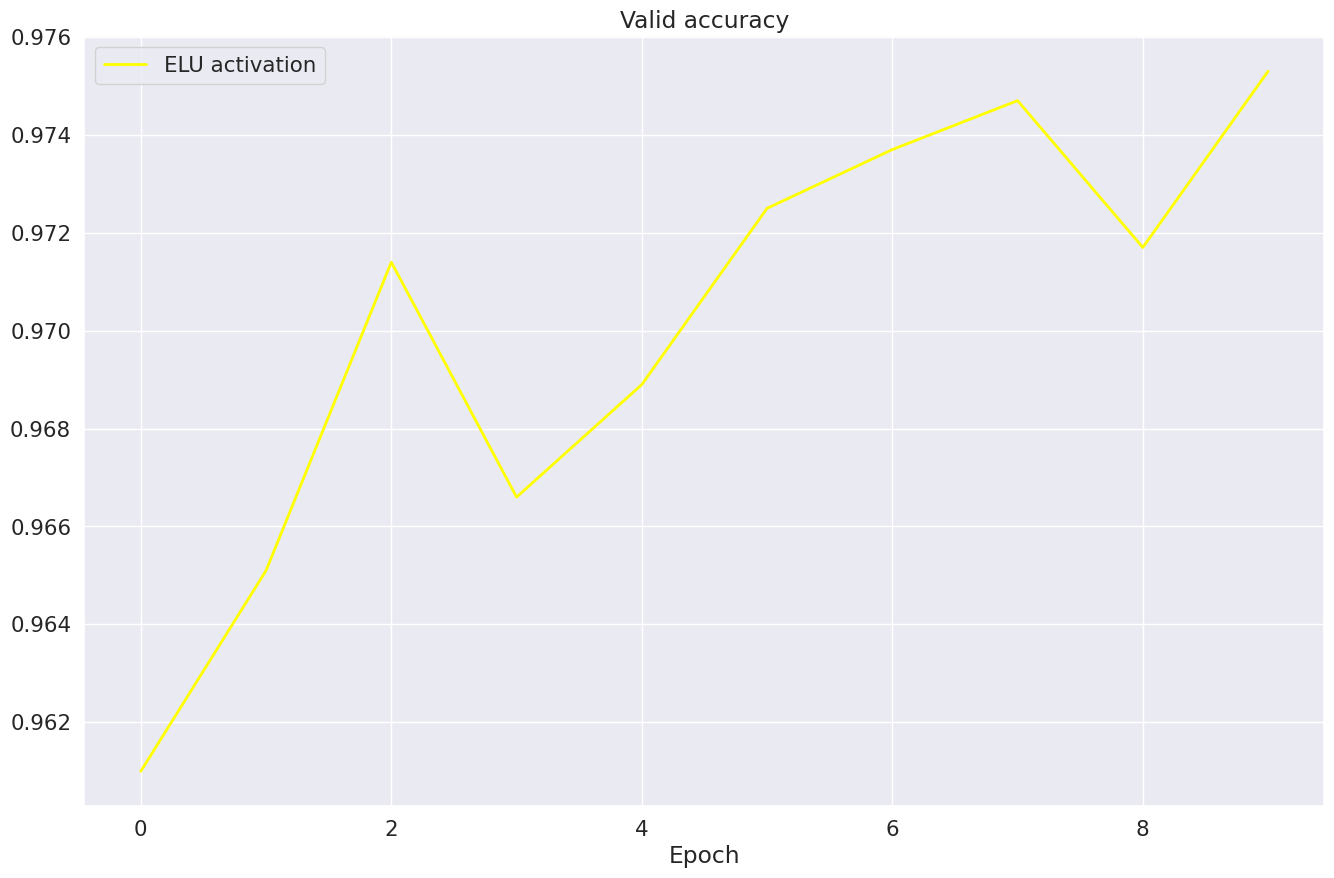

In [38]:
sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), elu_accuracy, label="ELU activation", linewidth=2, color = 'yellow')
plt.legend()
plt.xlabel("Epoch")
plt.show()

# Реализация модели LeNet

In [39]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fl = nn.Flatten()
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)
        x = self.fl(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

In [40]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [41]:
model_LeNet = LeNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_LeNet.parameters())

loaders_MNIST = {"train": train_dataloader_MNIST, "valid": valid_dataloader_MNIST}

In [42]:
max_epochs = 10
lenet_accuracy = train_func(
    model=model_LeNet,
    num_epochs=max_epochs,
    dataloaders=loaders_MNIST,
    optimizer=optimizer,
    loss_func=criterion
)

print("LeNet validation accuracy:", lenet_accuracy["valid"])


Epoch: 1


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy_train: 0.8886666666666667



  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy_test: 0.9693


Epoch: 2


...

Accuracy_test: 0.9888


Epoch: 10


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy_train: 0.9936666666666667



  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy_test: 0.9902

LeNet validation accuracy: [0.9693, 0.979, 0.9827, 0.9869, 0.9873, 0.9884, 0.987, 0.9875, 0.9888, 0.9902]


In [43]:
lenet_accuracy = lenet_accuracy["valid"]

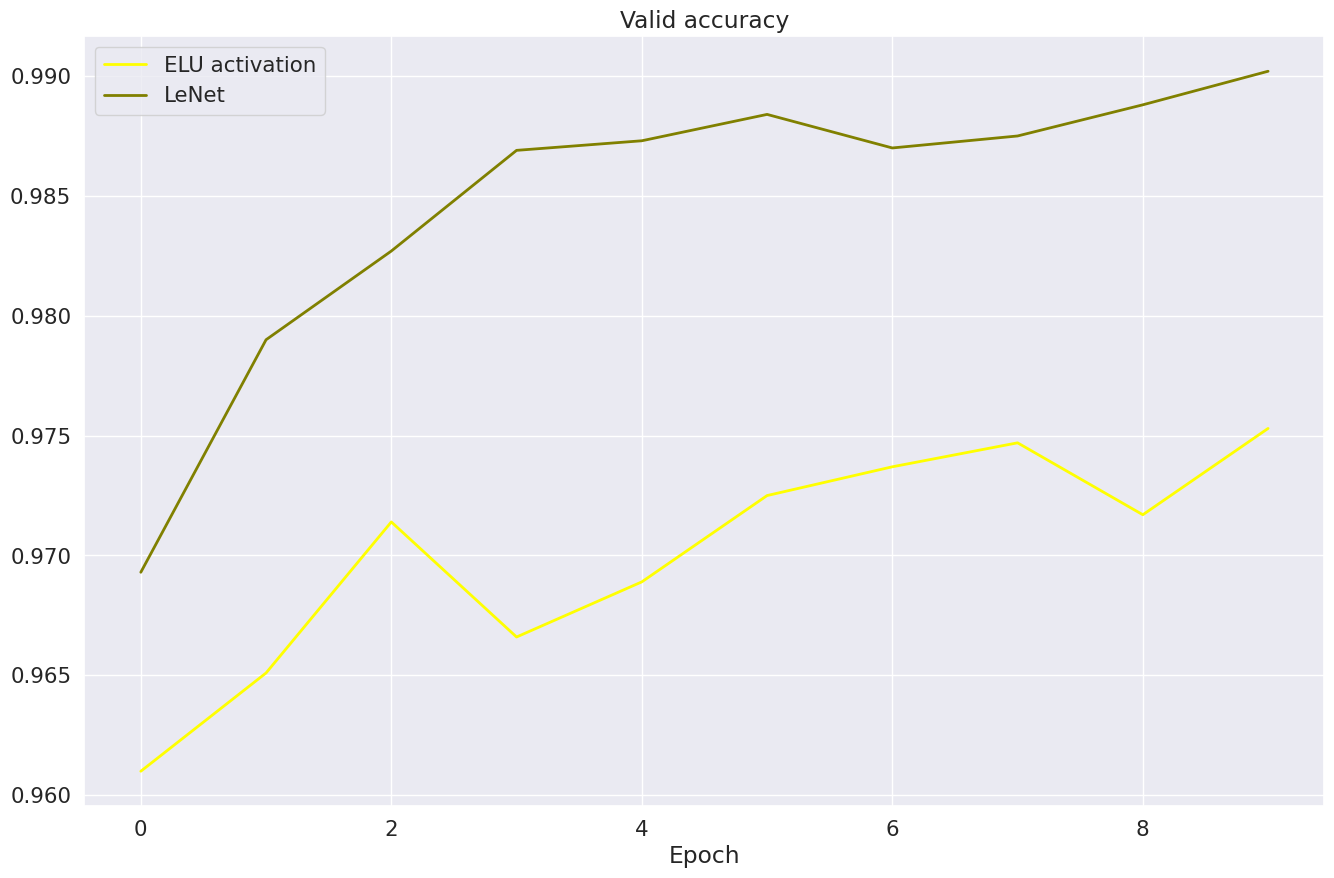

In [44]:
sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), elu_accuracy, label="ELU activation", linewidth=2, color = 'yellow')
plt.plot(range(max_epochs), lenet_accuracy, label="LeNet", linewidth=2, color = 'olive')
plt.legend()
plt.xlabel("Epoch")
plt.show()

In [45]:
lenet_accuracy

[0.9693, 0.979, 0.9827, 0.9869, 0.9873, 0.9884, 0.987, 0.9875, 0.9888, 0.9902]

In [21]:
class LeNet_BN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3)
        self.bn1 = nn.BatchNorm2d(6)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(6, 16, 3)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.fl = nn.Flatten()
        self.fc1 = nn.Linear(400, 120)
        self.bn3 = nn.BatchNorm1d(120)
        self.drop1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(120, 84)
        self.bn4 = nn.BatchNorm1d(84)
        self.drop2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(84, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.fl(x)
        x = self.drop1(self.relu(self.bn3(self.fc1(x))))
        x = self.drop2(self.relu(self.bn4(self.fc2(x))))
        x = self.fc3(x)
        return x

In [69]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [25]:
model_LeNet_BN = LeNet_BN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_LeNet_BN.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

loaders_MNIST = {"train": train_dataloader_MNIST, "valid": valid_dataloader_MNIST}

In [77]:
max_epochs = 30
lenet_bn_accuracy = train_func(
    model=model_LeNet_BN,
    num_epochs=max_epochs,
    dataloaders=loaders_MNIST,
    optimizer=optimizer,
    loss_func=criterion,
    scheduler=scheduler
)

print("LeNet validation accuracy:", lenet_bn_accuracy["valid"])


Epoch: 1


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy_train: 0.9347


  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy_test: 0.9814
Current learning rate: 0.001

Epoch: 2


...

Accuracy_test: 0.9922
Current learning rate: 6.25e-05

Epoch: 30


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy_train: 0.9979


  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy_test: 0.9921
Current learning rate: 6.25e-05
LeNet validation accuracy: [0.9814, 0.9882, 0.9883, 0.988, 0.9876, 0.9898, 0.9896, 0.9896, 0.9896, 0.9903, 0.9916, 0.9896, 0.9902, 0.9913, 0.9908, 0.9923, 0.9921, 0.9915, 0.991, 0.991, 0.9916, 0.9919, 0.992, 0.9919, 0.9922, 0.9915, 0.9919, 0.9921, 0.9922, 0.9921]


In [78]:
lenet_bn_accuracy = lenet_bn_accuracy['valid']

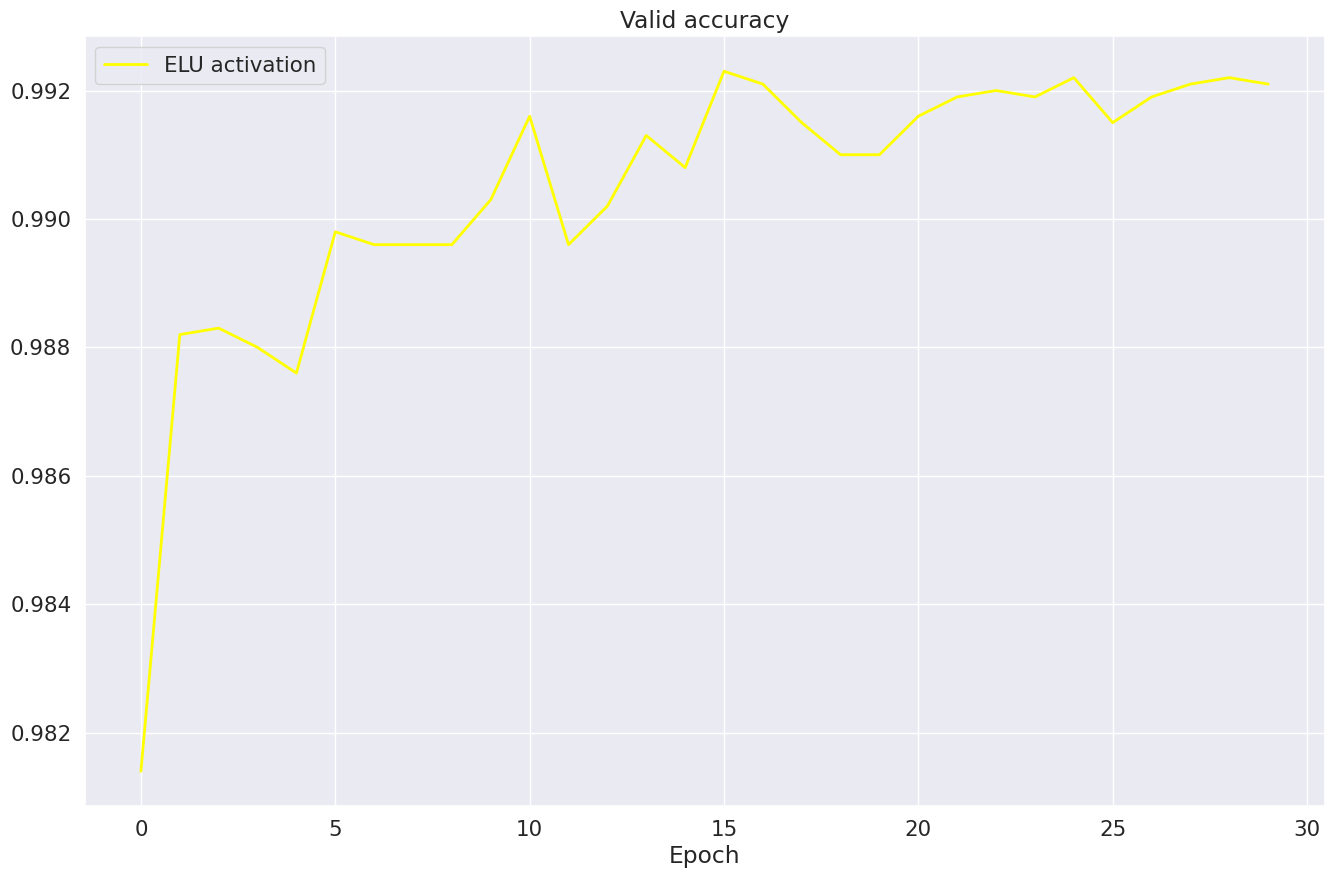

In [79]:
sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), lenet_bn_accuracy, label="ELU activation", linewidth=2, color = 'yellow')
plt.legend()
plt.xlabel("Epoch")
plt.show()

In [9]:
class CNN6(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.conv1_1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1_1 = nn.BatchNorm2d(32)
        self.conv1_2 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn1_2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2_1 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2_1 = nn.BatchNorm2d(64)
        self.conv2_2 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn2_2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3_1 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3_1 = nn.BatchNorm2d(128)
        self.conv3_2 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn3_2 = nn.BatchNorm2d(128)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(128, 10)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.bn1_1(self.conv1_1(x)))
        x = self.relu(self.bn1_2(self.conv1_2(x)))
        x = self.pool1(x)

        x = self.relu(self.bn2_1(self.conv2_1(x)))
        x = self.relu(self.bn2_2(self.conv2_2(x)))
        x = self.pool2(x)

        x = self.relu(self.bn3_1(self.conv3_1(x)))
        x = self.relu(self.bn3_2(self.conv3_2(x)))
        x = self.global_pool(x)

        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [82]:
model_CNN6 = CNN6().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_CNN6.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

loaders_MNIST = {"train": train_dataloader_MNIST, "valid": valid_dataloader_MNIST}

In [85]:
max_epochs = 5
lenet_bn_accuracy = train_func(
    model=model_CNN6,
    num_epochs=max_epochs,
    dataloaders=loaders_MNIST,
    optimizer=optimizer,
    loss_func=criterion,
    scheduler=scheduler
)

print("LeNet validation accuracy:", lenet_bn_accuracy["valid"])


Epoch: 1


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy_train: 0.9807


  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy_test: 0.9860
Current learning rate: 0.001

Epoch: 2


...

Accuracy_test: 0.9896
Current learning rate: 0.001

Epoch: 5


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy_train: 0.9943


  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy_test: 0.9905
Current learning rate: 0.001
LeNet validation accuracy: [0.986, 0.9868, 0.9893, 0.9896, 0.9905]


Итого лучший результат вышел для LeNet_BN: **accuracy = 0.92.**

Посмотрим, как изменится результат при аугментации train изображений. Ожидается небольшое улучшение качества.

In [31]:
from torchvision import datasets, transforms

temp_transform = transforms.Compose([transforms.ToTensor()])

temp_train = datasets.MNIST(root='./data', train=True, download=True, transform=temp_transform)

loader = torch.utils.data.DataLoader(temp_train, batch_size=1000, shuffle=False)

mean = 0.
std = 0.
total_pixels = 0

for images, _ in loader:
    batch_pixels = images.numel()
    mean += images.sum().item()
    total_pixels += batch_pixels

mean = mean / total_pixels

for images, _ in loader:
    batch_pixels = images.numel()
    std += ((images - mean) ** 2).sum().item()

std = (std / total_pixels) ** 0.5

print(f"Mean: {mean:.4f}, Std: {std:.4f}")

Mean: 0.1307, Std: 0.3081


In [33]:
MEAN = mean
STD = std

train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(MEAN,), std=(STD,))
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(MEAN,), std=(STD,))
])

In [42]:
train_dataset = datasets.MNIST(
    root='./data', train=True, download=True,
    transform=train_transform
)
valid_dataset = datasets.MNIST(
    root='./data', train=False, download=True,
    transform=eval_transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=128, shuffle=False)

loaders_MNIST = {"train": train_loader, "valid": valid_loader}

In [43]:
model_LeNet_BN = LeNet_BN().to(device)
optimizer = torch.optim.Adam(model_LeNet_BN.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

max_epochs = 72
lenet_bn_accuracy = train_func(
    model=model_LeNet_BN,
    num_epochs=max_epochs,
    dataloaders=loaders_MNIST,
    optimizer=optimizer,
    loss_func=criterion,
    scheduler=scheduler
)

print("LeNet + BN validation accuracy:", lenet_bn_accuracy["valid"])


Epoch: 1


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy_train: 0.8554


  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy_test: 0.9775
Current learning rate: 0.001

Epoch: 2


...

Accuracy_test: 0.9944
Current learning rate: 3.90625e-06

Epoch: 72


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy_train: 0.9860


  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy_test: 0.9942
Current learning rate: 3.90625e-06
LeNet + BN validation accuracy: [0.9775, 0.9861, 0.9863, 0.989, 0.9878, 0.9893, 0.9893, 0.9906, 0.9904, 0.9906, 0.9906, 0.9919, 0.9911, 0.9913, 0.9908, 0.9927, 0.9925, 0.9923, 0.9915, 0.9929, 0.993, 0.9921, 0.9931, 0.9927, 0.9929, 0.9934, 0.9926, 0.9931, 0.9926, 0.9931, 0.9936, 0.9936, 0.9937, 0.9936, 0.9933, 0.9936, 0.9938, 0.9933, 0.9937, 0.9925, 0.9938, 0.9938, 0.9938, 0.9937, 0.9934, 0.9932, 0.9934, 0.9938, 0.9934, 0.9942, 0.9942, 0.9943, 0.9941, 0.9941, 0.9938, 0.994, 0.9943, 0.9939, 0.9939, 0.994, 0.9942, 0.9943, 0.9943, 0.9942, 0.9943, 0.9941, 0.9943, 0.9938, 0.994, 0.9938, 0.9944, 0.9942]


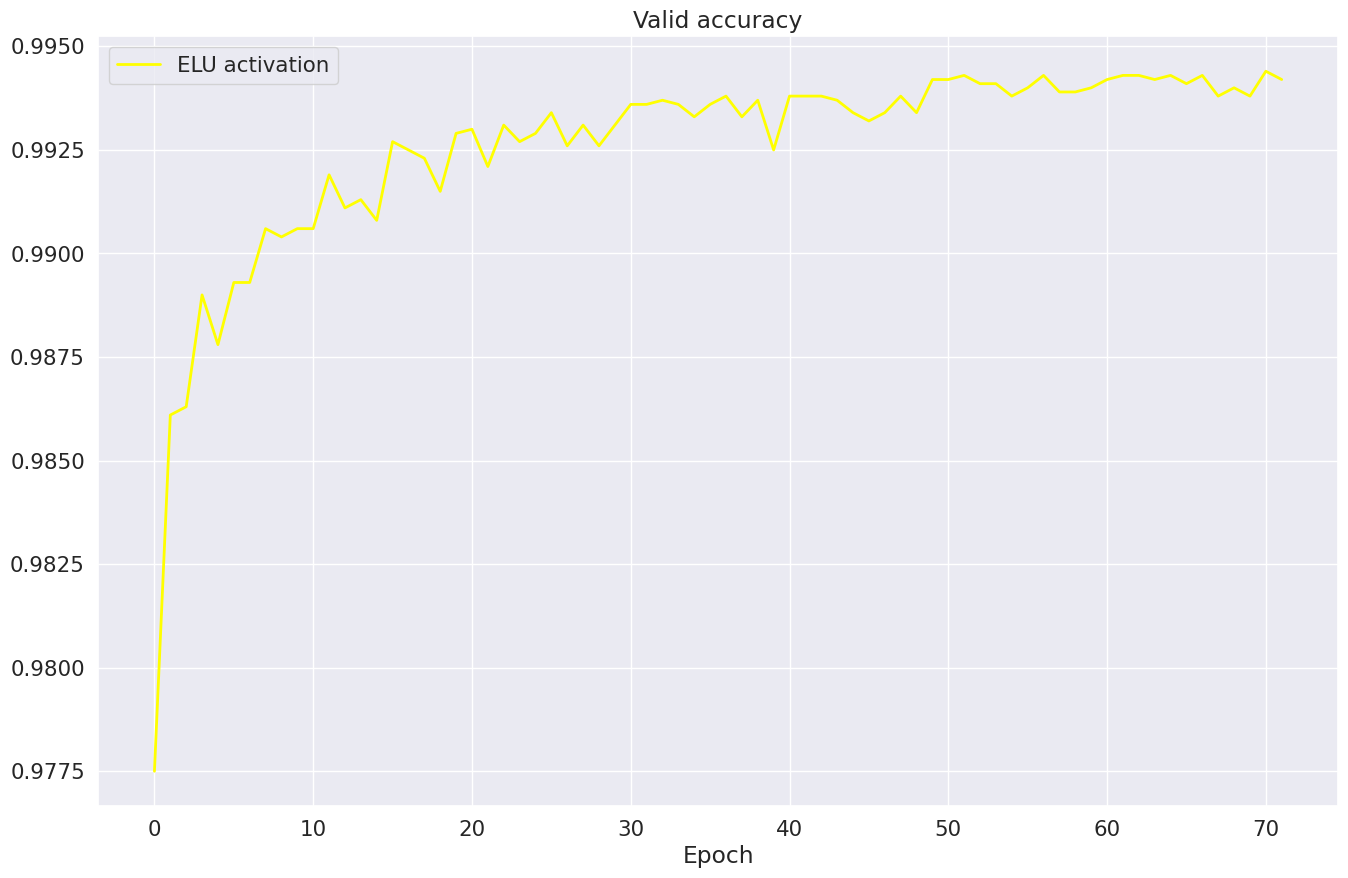

In [44]:
lenet_bn_accuracy = lenet_bn_accuracy['valid']

sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), lenet_bn_accuracy, label="ELU activation", linewidth=2, color = 'yellow')
plt.legend()
plt.xlabel("Epoch")
plt.show()

Видим, что с батч-нормализацией и аугментацией данных точность достигла 99.4% - прекрасный результат!